# Final Results

This notebook assembles the validated Queue-Reactive results into a single publication-oriented document. It is strictly **load-only**: no simulation, no recalibration, no order-book reconstruction, and no expensive fallback path are triggered here.

Only the following models are retained throughout the analysis:

- Real market data
- QR
- FTQR
- SAQR


## 1. Setup

The notebook loads precomputed tables from `data/processed/`. If one required artifact is missing, execution stops immediately with a clear error message.


In [48]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

KEEP_MODELS = ["Real", "QR", "FTQR", "SAQR"]
MODEL_COLORS = {
    "Real": "#111111",
    "QR": "#f58518",
    "FTQR": "#54a24b",
    "SAQR": "#b279a2",
}
MODEL_MARKERS = {
    "QR": "o",
    "FTQR": "s",
    "SAQR": "^",
}

FILE_LOCATIONS = {
    "final_results_summary.json": [ROOT / "data/processed/final_results_summary.json"],
    "descriptive_stats_level.csv": [ROOT / "data/processed/final_descriptive_stats_level.csv", ROOT / "data/processed/remote_results/stylized_facts/descriptive_stats_level.csv"],
    "qr_intensities.parquet": [ROOT / "data/processed/qr_intensities.parquet"],
    "common_intensity.parquet": [ROOT / "data/processed/remote_results_saqr_test/qr_model_validation/common_intensity.parquet"],
    "ftqr_intensity.parquet": [ROOT / "data/processed/remote_results_saqr_test/qr_model_validation/ftqr_intensity.parquet"],
    "saqr_aes.parquet": [ROOT / "data/processed/remote_results_saqr_test/qr_model_validation/saqr_aes.parquet"],
    "order_size_distribution.parquet": [ROOT / "data/processed/remote_results/stylized_facts/order_size_distribution.parquet"],
    "traded_volume_10min.parquet": [ROOT / "data/processed/remote_results/stylized_facts/traded_volume_10min.parquet"],
    "traded_volume_summary.csv": [ROOT / "data/processed/remote_results/stylized_facts/traded_volume_summary.csv"],
    "trade_interarrival_hist.parquet": [ROOT / "data/processed/remote_results/stylized_facts/trade_interarrival_hist.parquet"],
    "trade_weibull_fit.csv": [ROOT / "data/processed/remote_results/stylized_facts/trade_weibull_fit.csv"],
    "trade_weibull_pdf.parquet": [ROOT / "data/processed/remote_results/stylized_facts/trade_weibull_pdf.parquet"],
    "queue_size_distribution.parquet": [ROOT / "data/processed/remote_results/stylized_facts/queue_size_distribution.parquet"],
    "queue_size_gamma_fit.parquet": [ROOT / "data/processed/remote_results/stylized_facts/queue_size_gamma_fit.parquet"],
    "queue_size_ks_summary.csv": [ROOT / "data/processed/remote_results/stylized_facts/queue_size_ks_summary.csv"],
}

def require_named_file(name: str) -> Path:
    for candidate in FILE_LOCATIONS[name]:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Missing precomputed file {name}. Checked: " + ", ".join(str(p) for p in FILE_LOCATIONS[name])
    )

summary = json.loads(require_named_file("final_results_summary.json").read_text())
desc_df = pd.read_csv(require_named_file("descriptive_stats_level.csv"))
qr_curves = pd.read_parquet(require_named_file("qr_intensities.parquet"))
common_intensity = pd.read_parquet(require_named_file("common_intensity.parquet"))
ftqr_intensity = pd.read_parquet(require_named_file("ftqr_intensity.parquet"))
saqr_aes = pd.read_parquet(require_named_file("saqr_aes.parquet"))
size_dist = pd.read_parquet(require_named_file("order_size_distribution.parquet"))
traded_10m = pd.read_parquet(require_named_file("traded_volume_10min.parquet"))
traded_summary = pd.read_csv(require_named_file("traded_volume_summary.csv"))
ia_hist = pd.read_parquet(require_named_file("trade_interarrival_hist.parquet"))
ia_fit = pd.read_csv(require_named_file("trade_weibull_fit.csv"))
ia_pdf = pd.read_parquet(require_named_file("trade_weibull_pdf.parquet"))
queue_dist = pd.read_parquet(require_named_file("queue_size_distribution.parquet"))
queue_gamma = pd.read_parquet(require_named_file("queue_size_gamma_fit.parquet"))
queue_ks_summary = pd.read_csv(require_named_file("queue_size_ks_summary.csv"))

size_dist = size_dist[size_dist["model"].isin(KEEP_MODELS)].copy()
traded_10m = traded_10m[traded_10m["model"].isin(KEEP_MODELS)].copy()
traded_summary = traded_summary[traded_summary["model"].isin([m for m in KEEP_MODELS if m != "Real"])].copy()
ia_hist = ia_hist[ia_hist["model"].isin(KEEP_MODELS)].copy()
ia_fit = ia_fit[ia_fit["model"].isin(KEEP_MODELS)].copy()
ia_pdf = ia_pdf[ia_pdf["model"].isin(KEEP_MODELS)].copy()
queue_dist = queue_dist[queue_dist["model"].isin(KEEP_MODELS)].copy()
queue_ks_summary = queue_ks_summary[queue_ks_summary["model"].isin(["QR", "FTQR", "SAQR"])].copy()

qr_points = qr_curves[(qr_curves["segment"] == "full_month") & (qr_curves["estimator"] == "state_duration")].copy()
qr_points = qr_points[["n", "lambda_L", "lambda_C", "lambda_M"]].sort_values("n")
qr_points = qr_points.rename(columns={
    "lambda_L": "lambda_L_qr",
    "lambda_C": "lambda_C_qr",
    "lambda_M": "lambda_M_qr",
})

display(pd.DataFrame({
    "Spread = 1 tick (%)": [summary["spread_eq_1_pct"]],
    "QR feature rows": [summary["n_rows"]],
    "Models retained": [", ".join(KEEP_MODELS)],
}))


,Spread = 1 tick (%),QR feature rows,Models retained
0,99.839876,6745412,"Real, QR, FTQR, SAQR"


## 2. Data and Descriptive Statistics

The reconstructed Bund order flow is overwhelmingly concentrated at a one-tick spread, with `spread = 1` for approximately **99.84%** of the QR-feature observations. This confirms the large-tick character of the contract and motivates the queue-reactive modeling framework.

### Table 1: Descriptive statistics of the reconstructed order flow (Level 1 to 5).


In [49]:
table1 = desc_df.copy()
table1["# Events (L/C/M)"] = (
    table1["Limit events"].map(lambda x: f"{int(x):,}") + " / " +
    table1["Cancel events"].map(lambda x: f"{int(x):,}") + " / " +
    table1["Market events"].map(lambda x: f"{int(x):,}")
)
table1 = table1[["Side", "Level", "# Events (L/C/M)", "AES", "AIT_seconds"]].rename(columns={"AIT_seconds": "AIT (seconds)"})
display(table1.style.format({"AES": "{:.2f}", "AIT (seconds)": "{:.6f}"}))


,Side,Level,# Events (L/C/M),AES,AIT (seconds)
0,bid,1,"375,259 / 363,032 / 32,195",8.04,0.931891
1,bid,2,"347,157 / 337,692 / 26,428",7.81,1.050619
2,bid,3,"334,052 / 325,331 / 25,948",7.99,1.096085
3,bid,4,"323,509 / 314,398 / 26,865",8.15,1.200174
4,bid,5,"299,148 / 291,935 / 23,872",8.26,1.294072
5,ask,1,"290,135 / 274,090 / 34,007",8.49,1.121400
6,ask,2,"293,523 / 281,964 / 28,592",7.90,1.164168
7,ask,3,"321,356 / 309,054 / 33,600",8.21,1.050878
8,ask,4,"349,663 / 336,496 / 34,996",8.67,0.982287
9,ask,5,"345,220 / 334,719 / 31,176",8.37,1.068839


## 3. Intensity Functions and Model Validation

### Figure 1: Calibrated intensities for the QR model.


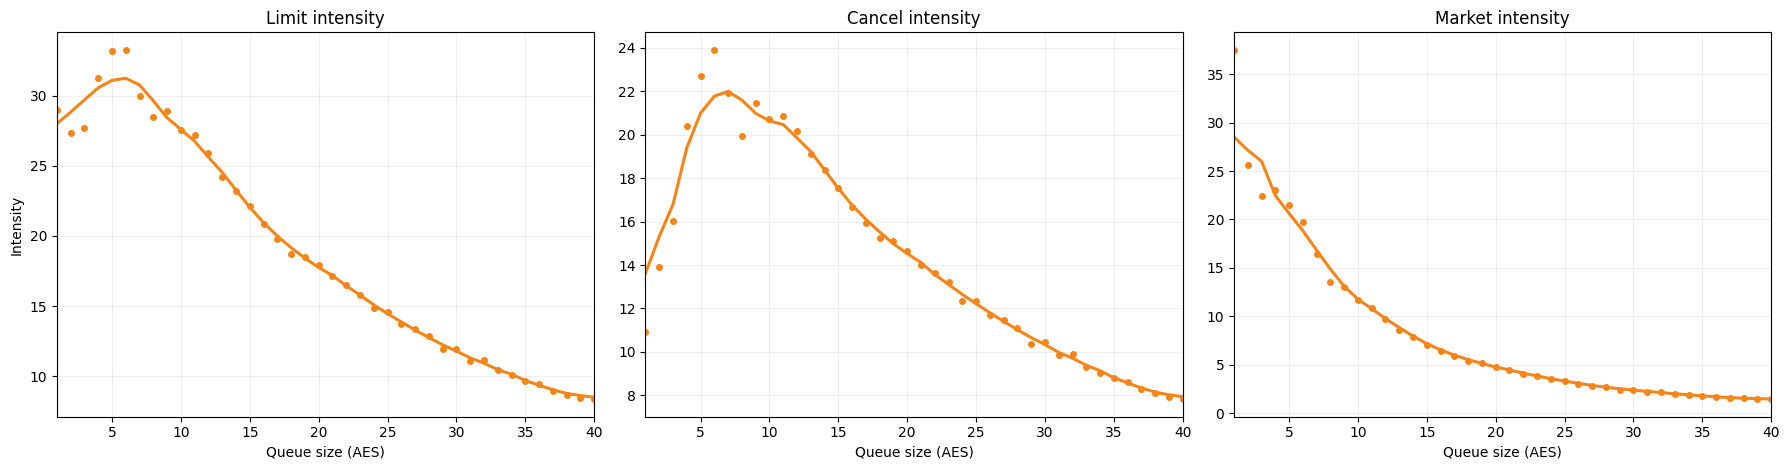

In [50]:
qr_plot = common_intensity[common_intensity["n"] <= 40].copy()
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharex=True)
for ax, col, title in zip(
    axes,
    ["lambda_L", "lambda_C", "lambda_M"],
    ["Limit intensity", "Cancel intensity", "Market intensity"],
):
    smooth = qr_plot[col].rolling(window=5, min_periods=1, center=True).mean()
    ax.plot(qr_plot["n"], smooth, color=MODEL_COLORS["QR"], linewidth=2.2)
    ax.plot(qr_plot["n"], qr_plot[col], linestyle="none", marker="o", markersize=4, color=MODEL_COLORS["QR"])
    ax.set_title(title)
    ax.set_xlabel("Queue size (AES)")
    ax.set_xlim(1, 40)
    ax.grid(alpha=0.2)
axes[0].set_ylabel("Intensity")
fig.tight_layout()


The QR calibration exhibits the expected structure: limit and cancel intensities are highest in the small-queue regime, while market intensity remains markedly decreasing as queue size increases.

### Figure 2: FTQR decomposition of intensities into partial and full-consumption events.


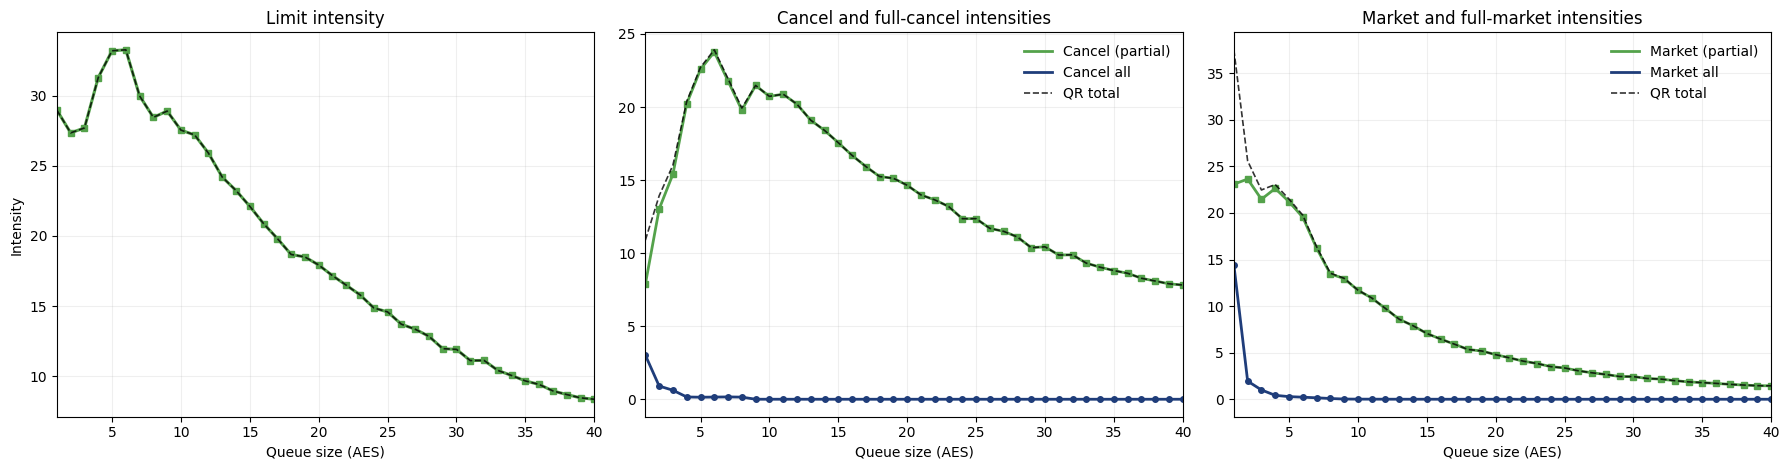

In [51]:
ftqr_plot = ftqr_intensity[ftqr_intensity["n"] <= 40].copy()
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharex=True)

axes[0].plot(ftqr_plot["n"], ftqr_plot["lambda_L"], color=MODEL_COLORS["FTQR"], linewidth=2.2)
axes[0].plot(ftqr_plot["n"], ftqr_plot["lambda_L"], linestyle="none", marker="s", markersize=4, color=MODEL_COLORS["FTQR"])
axes[0].plot(qr_plot["n"], qr_plot["lambda_L"], color="black", linestyle="--", linewidth=1.2, alpha=0.8)
axes[0].set_title("Limit intensity")

axes[1].plot(ftqr_plot["n"], ftqr_plot["lambda_C"], color=MODEL_COLORS["FTQR"], linewidth=2.0, label="Cancel (partial)")
axes[1].plot(ftqr_plot["n"], ftqr_plot["lambda_C"], linestyle="none", marker="s", markersize=4, color=MODEL_COLORS["FTQR"])
axes[1].plot(ftqr_plot["n"], ftqr_plot["lambda_C_all"], color="#1f3d7a", linewidth=2.0, label="Cancel all")
axes[1].plot(ftqr_plot["n"], ftqr_plot["lambda_C_all"], linestyle="none", marker="o", markersize=4, color="#1f3d7a")
axes[1].plot(qr_plot["n"], qr_plot["lambda_C"], color="black", linestyle="--", linewidth=1.2, alpha=0.8, label="QR total")
axes[1].set_title("Cancel and full-cancel intensities")
axes[1].legend(frameon=False)

axes[2].plot(ftqr_plot["n"], ftqr_plot["lambda_M"], color=MODEL_COLORS["FTQR"], linewidth=2.0, label="Market (partial)")
axes[2].plot(ftqr_plot["n"], ftqr_plot["lambda_M"], linestyle="none", marker="s", markersize=4, color=MODEL_COLORS["FTQR"])
axes[2].plot(ftqr_plot["n"], ftqr_plot["lambda_M_all"], color="#1f3d7a", linewidth=2.0, label="Market all")
axes[2].plot(ftqr_plot["n"], ftqr_plot["lambda_M_all"], linestyle="none", marker="o", markersize=4, color="#1f3d7a")
axes[2].plot(qr_plot["n"], qr_plot["lambda_M"], color="black", linestyle="--", linewidth=1.2, alpha=0.8, label="QR total")
axes[2].set_title("Market and full-market intensities")
axes[2].legend(frameon=False)

for ax in axes:
    ax.set_xlabel("Queue size (AES)")
    ax.set_xlim(1, 40)
    ax.grid(alpha=0.2)
axes[0].set_ylabel("Intensity")
fig.tight_layout()


FTQR preserves the total QR intensity while redistributing cancel and market activity between partial and full-consumption events. This is particularly visible in the small-queue regime, where the full-consumption components become economically relevant.

### Figure 3: SAQR intensity heatmap (normalized by AES).

The first row reports `log(1 + count)` support, which shows where the observations are concentrated. The second row reports row-normalized conditional intensity, which is the most informative representation for assessing diagonal dominance. For cancel and market orders, the non-meaningful upper-triangular region `order size > queue size` is masked.


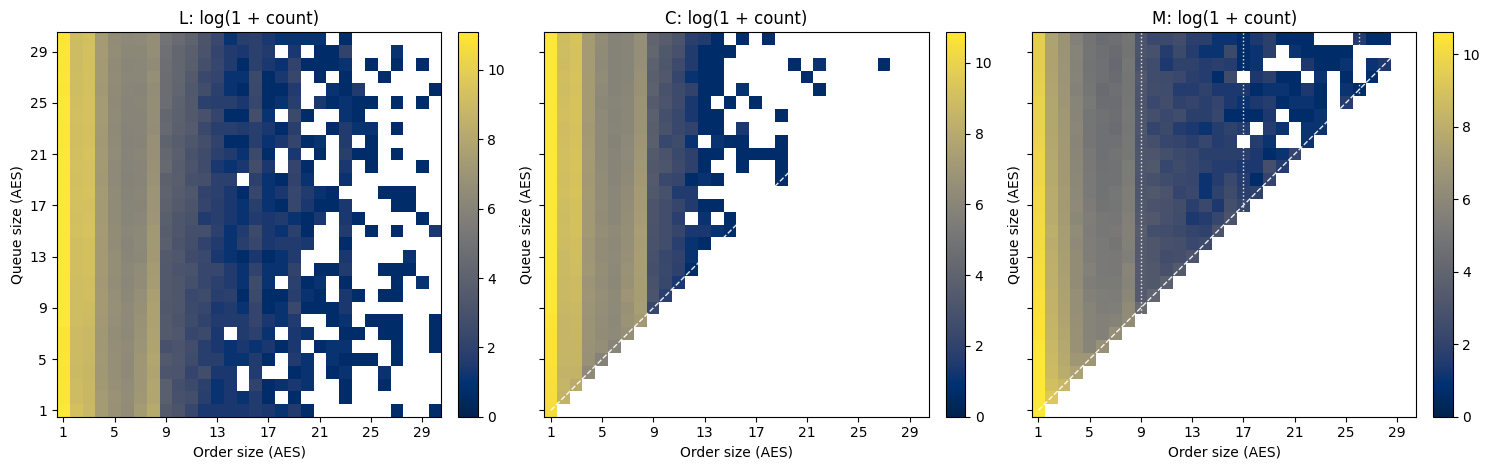

In [52]:
AES_CROP_MAX = 30
cmap = plt.get_cmap("cividis")

def build_heatmap(df, eta, value_col, triangular):
    sub = df[(df["eta"] == eta) & (df["n"] <= AES_CROP_MAX) & (df["size_aes"] <= AES_CROP_MAX)].copy()
    heat = sub.pivot(index="n", columns="size_aes", values=value_col).sort_index().sort_index(axis=1)
    heat = heat.reindex(index=range(1, AES_CROP_MAX + 1), columns=range(1, AES_CROP_MAX + 1))
    if triangular:
        for n in heat.index:
            heat.loc[n, heat.columns > n] = np.nan
    return heat

def plot_heat(ax, heat, title, vmin=None, vmax=None, add_diag=False, round_buckets=None):
    masked = np.ma.masked_invalid(heat.to_numpy(dtype=float))
    im = ax.imshow(
        masked,
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        cmap=cmap,
        extent=[0.5, AES_CROP_MAX + 0.5, 0.5, AES_CROP_MAX + 0.5],
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(title)
    ax.set_xlabel("Order size (AES)")
    ax.set_ylabel("Queue size (AES)")
    ax.set_xticks(np.arange(1, AES_CROP_MAX + 1, 4))
    ax.set_yticks(np.arange(1, AES_CROP_MAX + 1, 4))
    if add_diag:
        ax.plot([1, AES_CROP_MAX], [1, AES_CROP_MAX], color="white", linestyle="--", linewidth=1.0, alpha=0.9)
    if round_buckets:
        for b in round_buckets:
            if b <= AES_CROP_MAX:
                ax.axvline(b, color="white", linestyle=":", linewidth=1.0, alpha=0.9)
    return im

support_df = saqr_aes.assign(log_count=np.log1p(saqr_aes["count"]))
support_maps = {eta: build_heatmap(support_df, eta, "log_count", triangular=(eta != "L")) for eta in ["L", "C", "M"]}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True, sharey=True)
for j, eta in enumerate(["L", "C", "M"]):
    heat = support_maps[eta]
    vmax = np.nanquantile(heat.to_numpy(dtype=float), 0.99)
    im = plot_heat(
        axes[j],
        heat,
        f"{eta}: log(1 + count)",
        vmin=0.0,
        vmax=vmax,
        add_diag=(eta != "L"),
        round_buckets=[9, 17, 26] if eta == "M" else None,
    )
    fig.colorbar(im, ax=axes[j], fraction=0.046, pad=0.04)
fig.tight_layout()



The limit-order heatmap remains comparatively stable across queue sizes, whereas cancel and market activity become much more concentrated near the diagonal. This concentration is strongest at low queue sizes, which is consistent with a higher probability of consuming the entire available liquidity when depth is limited. The market-order panels also show salient activity around 9, 17, and 26 AES, which correspond to round sizes near 50, 100, and 150 lots.

## 4. Distribution of Order Sizes

### Figure 4: Distribution of order sizes (log-log scale).


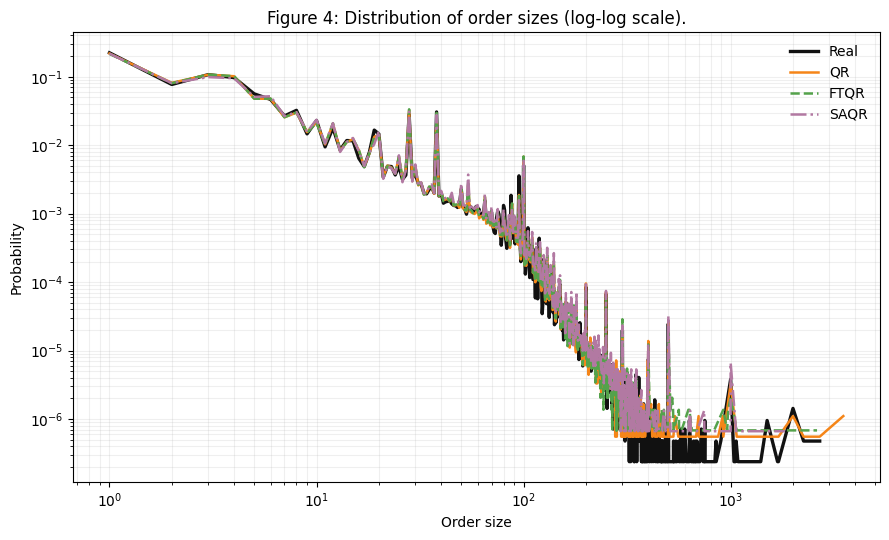

In [53]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for model, ls, lw in [("Real", '-', 2.4), ("QR", '-', 1.8), ("FTQR", '--', 1.8), ("SAQR", '-.', 1.8)]:
    sub = size_dist[(size_dist["model"] == model) & (size_dist["size"] > 0) & (size_dist["probability"] > 0)].sort_values("size")
    ax.plot(sub["size"], sub["probability"], color=MODEL_COLORS[model], linestyle=ls, linewidth=lw, marker=None, label=model)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Order size')
ax.set_ylabel('Probability')
ax.set_title('Figure 4: Distribution of order sizes (log-log scale).')
ax.grid(alpha=0.2, which='both')
ax.legend(frameon=False)
fig.tight_layout()


The traded-volume benchmark is evaluated over three intraday regimes: the full trading day (09:00-18:00), a calmer midday window (10:00-14:00), and the more active late session (15:00-18:00). The figure below reports the mean traded volume per 10-minute window across the selected days, while Table 2 summarizes the relative-difference and quadratic-error metrics used for model comparison.

## 5. Traded Volume Comparison

### Figure 5: Traded volumes in 10-minute windows across intraday regimes.


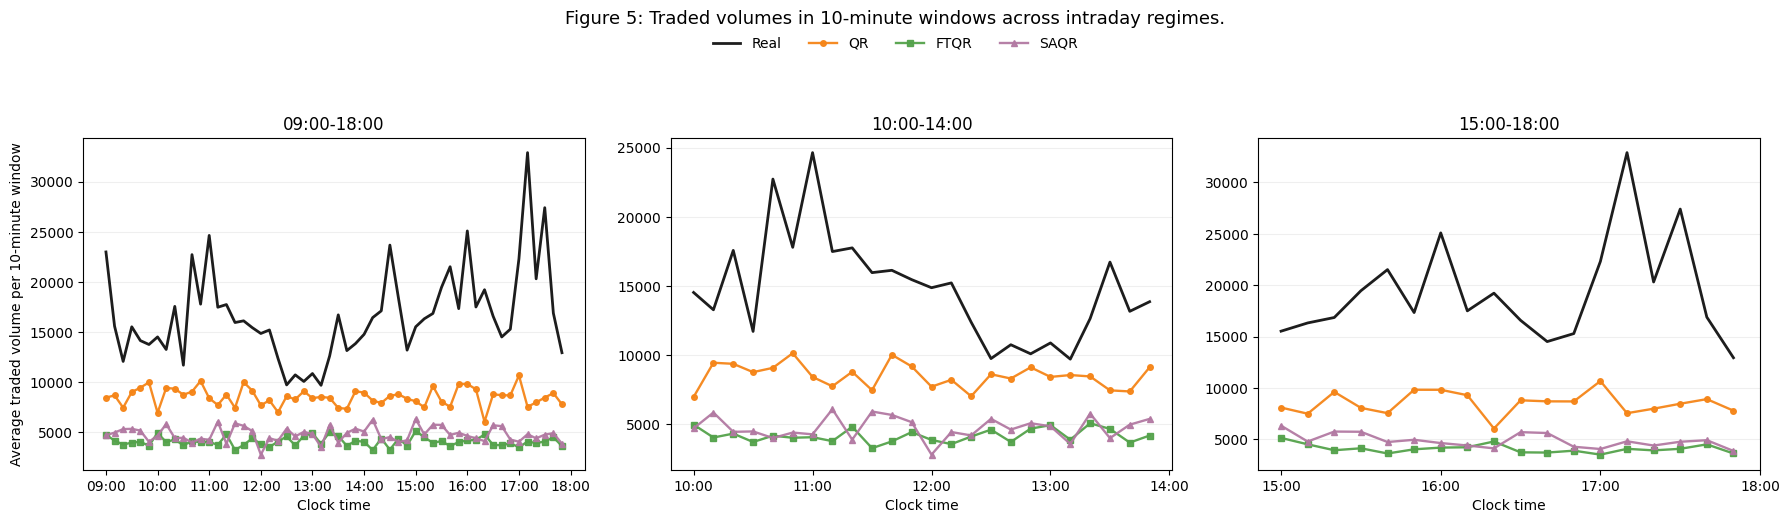

In [54]:
traded_10m_plot = traded_10m.copy()
traded_10m_plot["window_start"] = pd.to_datetime(traded_10m_plot["window_start"])
traded_10m_plot["tod_minutes"] = traded_10m_plot["window_start"].dt.hour * 60 + traded_10m_plot["window_start"].dt.minute
traded_10m_plot["tod_label"] = traded_10m_plot["window_start"].dt.strftime("%H:%M")

period_windows = [
    ("09:00-18:00", 9 * 60, 18 * 60),
    ("10:00-14:00", 10 * 60, 14 * 60),
    ("15:00-18:00", 15 * 60, 18 * 60),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharey=False)
for ax, (period_label, start_min, end_min) in zip(axes, period_windows):
    period_df = traded_10m_plot[(traded_10m_plot["tod_minutes"] >= start_min) & (traded_10m_plot["tod_minutes"] < end_min)].copy()
    avg_df = (
        period_df.groupby(["model", "tod_minutes", "tod_label"], as_index=False)["traded_volume"]
        .mean()
        .sort_values(["model", "tod_minutes"])
    )
    for model in KEEP_MODELS:
        sub = avg_df[avg_df["model"] == model].copy()
        if sub.empty:
            continue
        x = sub["tod_minutes"].to_numpy()
        ax.plot(
            x,
            sub["traded_volume"],
            color=MODEL_COLORS[model],
            linewidth=2.0 if model == "Real" else 1.7,
            marker=None if model == "Real" else MODEL_MARKERS.get(model, "o"),
            markersize=4.0 if model != "Real" else 0,
            label=model,
            alpha=0.95,
        )
    tick_positions = np.arange(start_min, end_min + 1, 60)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([f"{int(t // 60):02d}:00" for t in tick_positions], rotation=0)
    ax.set_title(period_label)
    ax.set_xlabel("Clock time")
    ax.grid(axis="y", alpha=0.2)
axes[0].set_ylabel("Average traded volume per 10-minute window")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.05))
fig.suptitle("Figure 5: Traded volumes in 10-minute windows across intraday regimes.", y=1.08, fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()


QR remains the closest to the empirical traded-volume scale across the three intraday regimes, while FTQR and SAQR underestimate traded volume more substantially on this selected subset of days. The ranking is stable across the calm midday period and the more active late session.

### Table 2: Statistics about traded volumes of simulated markets during different periods of the day.


In [55]:
period_order = ["09:00-18:00", "10:00-14:00", "15:00-18:00"]
table2 = traded_summary.copy()
table2 = table2.rename(columns={
    "model": "Model",
    "period": "Period",
    "avg_relative_difference_pct": "Relative Difference (%)",
    "avg_quadratic_error": "Quadratic Error",
})
table2 = table2[["Period", "Model", "Relative Difference (%)", "Quadratic Error"]].copy()
table2["Period"] = pd.Categorical(table2["Period"], categories=period_order, ordered=True)
table2["Model"] = pd.Categorical(table2["Model"], categories=["QR", "FTQR", "SAQR"], ordered=True)
table2 = table2.sort_values(["Period", "Model"]).reset_index(drop=True)
display(table2.style.format({"Relative Difference (%)": "{:+.2f}", "Quadratic Error": "{:.2e}"}))


,Period,Model,Relative Difference (%),Quadratic Error
0,09:00-18:00,QR,-48.10,2.05e+11
1,09:00-18:00,FTQR,-75.05,4.75e+11
2,09:00-18:00,SAQR,-70.61,4.26e+11
3,10:00-14:00,QR,-39.89,2.95e+10
4,10:00-14:00,FTQR,-70.28,7.24e+10
5,10:00-14:00,SAQR,-66.44,6.50e+10
6,15:00-18:00,QR,-55.66,3.84e+10
7,15:00-18:00,FTQR,-78.72,7.55e+10
8,15:00-18:00,SAQR,-74.53,6.82e+10


The traded-volume statistics confirm that all three simulated models remain below the empirical benchmark, but the gap is materially smaller for QR than for FTQR and SAQR. This is true for the full session, the 10:00-14:00 window, and the 15:00-18:00 window.

## 6. Weibull Fit of Trade Interarrival Times

### Figure 6: Weibull fit of trade interarrival times.


,model,shape_k,scale_lambda,n_obs,mean_interarrival
0,FTQR,0.809,0.0922,"128,187",0.1042
1,QR,0.769,0.0660,"173,281",0.0780
3,Real,0.218,0.0246,"207,362",0.7811
4,SAQR,0.752,0.0804,"143,806",0.0966


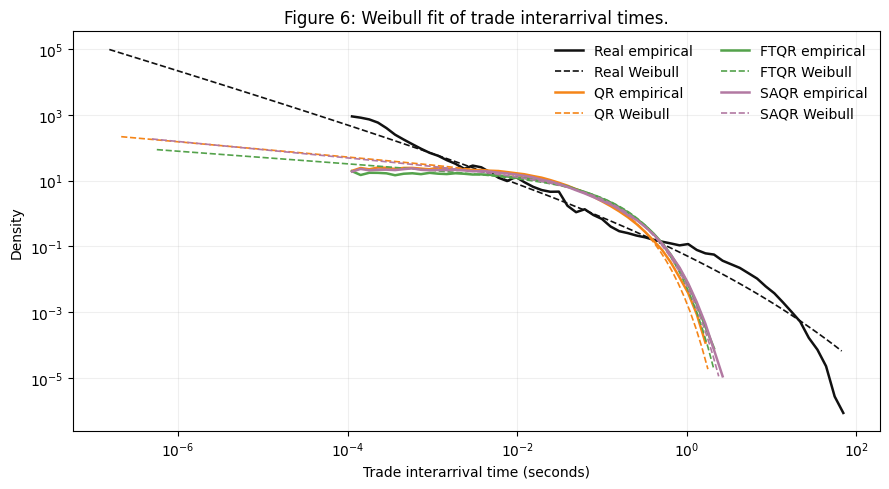

In [56]:
fig, ax = plt.subplots(figsize=(9, 5))
for model in KEEP_MODELS:
    hist_sub = ia_hist[ia_hist["model"] == model].copy()
    hist_sub = hist_sub[(hist_sub["bin_left"] > 0) & (hist_sub["bin_right"] > 0) & (hist_sub["density"] > 0)]
    x = np.sqrt(hist_sub["bin_left"] * hist_sub["bin_right"])
    ax.plot(x, hist_sub["density"], linewidth=1.8, label=f"{model} empirical", color=MODEL_COLORS[model])

    pdf_sub = ia_pdf[ia_pdf["model"] == model].copy()
    pdf_sub = pdf_sub[(pdf_sub["interarrival"] > 0) & (pdf_sub["weibull_pdf"] > 0)]
    if not pdf_sub.empty:
        ax.plot(
            pdf_sub["interarrival"],
            pdf_sub["weibull_pdf"],
            linestyle="--",
            linewidth=1.2,
            color=MODEL_COLORS[model],
            label=f"{model} Weibull",
        )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Trade interarrival time (seconds)")
ax.set_ylabel("Density")
ax.set_title("Figure 6: Weibull fit of trade interarrival times.")
ax.grid(alpha=0.2, which="both")
ax.legend(frameon=False, ncol=2)
fig.tight_layout()

display(ia_fit.style.format({"shape_k": "{:.3f}", "scale_lambda": "{:.4f}", "mean_interarrival": "{:.4f}", "n_obs": "{:,.0f}"}))



The figure compares the empirical trade interarrival distribution with the corresponding Weibull benchmark on log-log scales. The Weibull fit is intended as a descriptive approximation rather than a structural claim about the true data-generating process.\n

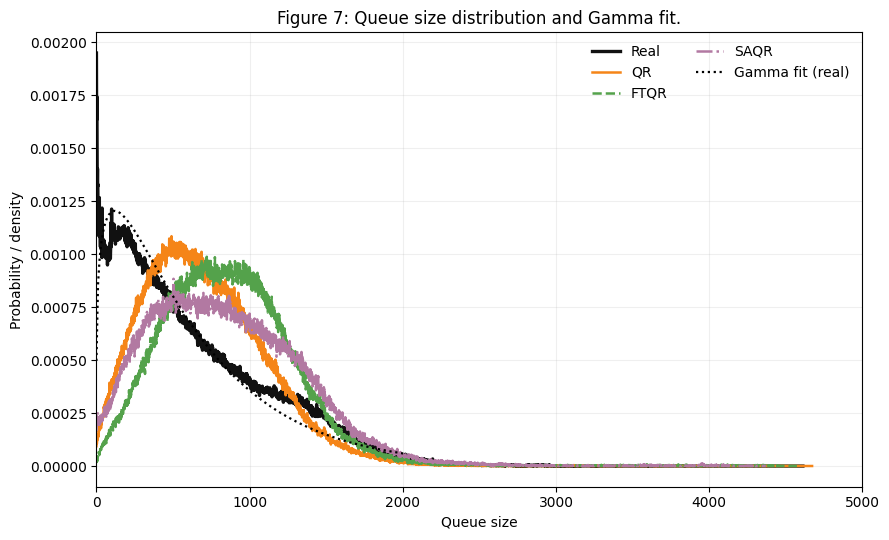

In [57]:
fig, ax = plt.subplots(figsize=(9, 5.5))
queue_plot = queue_dist[queue_dist["queue_size"] <= 5000].copy()
gamma_plot = queue_gamma[queue_gamma["queue_size"] <= 5000].copy()
for model, ls, lw in [("Real", '-', 2.4), ("QR", '-', 1.8), ("FTQR", '--', 1.8), ("SAQR", '-.', 1.8)]:
    sub = queue_plot[(queue_plot["model"] == model) & (queue_plot["probability"] > 0)].sort_values("queue_size")
    ax.plot(sub["queue_size"], sub["probability"], color=MODEL_COLORS[model], linestyle=ls, linewidth=lw, label=model)
ax.plot(gamma_plot["queue_size"], gamma_plot["gamma_pdf"], color='black', linestyle=':', linewidth=1.6, label='Gamma fit (real)')
ax.set_xlim(0, 5000)
ax.set_xlabel('Queue size')
ax.set_ylabel('Probability / density')
ax.set_title('Figure 7: Queue size distribution and Gamma fit.')
ax.grid(alpha=0.2)
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
plt.show()


## 7. Queue Size Distribution and Gamma Fit

### Figure 7: Queue size distribution and Gamma fit.

The empirical queue-size distribution is concentrated near the origin but retains a visibly heavy right tail. QR remains the closest of the retained simulated models to the empirical benchmark in distributional terms, while FTQR and SAQR generate thicker deviations at the best level.

### Table 3: KS statistics for queue size distributions.


In [58]:
table3 = queue_ks_summary[["model", "mean", "std"]].copy()
table3 = table3.rename(columns={"model": "Model", "mean": "Mean KS", "std": "Std KS"})
table3["Model"] = pd.Categorical(table3["Model"], categories=["QR", "FTQR", "SAQR"], ordered=True)
table3 = table3.sort_values("Model").reset_index(drop=True)
display(table3.style.format({"Mean KS": "{:.4f}", "Std KS": "{:.4f}"}))


,Model,Mean KS,Std KS
0,QR,0.1788,0.0181
1,FTQR,0.2937,0.0215
2,SAQR,0.2249,0.0347


## 8. Summary

Across the reconstructed Bund sample, the market is effectively at a one-tick spread almost all the time, confirming its large-tick nature. The QR calibration already captures the main intensity structure; FTQR enriches the interpretation of small-queue consumption through explicit full-depletion channels; and SAQR provides the clearest evidence that order-size behavior depends on queue state, especially for cancel and market orders. At the same time, the stylized-fact comparisons show that reproducing empirical traded volume, trade clustering, and queue-size distributions remains challenging even for the richer model variants.
